In [1]:
#! Mount Drive and import only the tools needed for frozen-output scoring
from google.colab import drive

drive.mount('/content/drive')

import ast
import hashlib
import importlib
import json
import os
import sys

from pathlib import Path

import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt

SEED = 6304

ROOT = Path('/content/drive/MyDrive/pa1-beyond-iid')

TASK = ROOT / 'task4'
CODE_DIR = TASK / 'code'
SPLIT_FILE = TASK / 'splits' / 'cifar10_stratified_90_10_seed6304.npz'
VANILLA_CONFIG = TASK / 'configs' / 'vanilla.json'
INITIAL_PATH = TASK / 'checkpoints' / 'shared_random_resnet18_seed6304.pt'
BEST_PATH = TASK / 'checkpoints' / 'vanilla' / 'best.pt'
LAST_PATH = TASK / 'checkpoints' / 'vanilla' / 'last.pt'
CACHE_DIR = TASK / 'cache' / 'vanilla'
SCORE_FILE = CODE_DIR / 'cifar_osr_scores_v1.py'
OUT_DIR = TASK / 'results' / 'posthoc'

print('CPU scoring notebook | PyTorch:', torch.__version__)
print('Task 4 root:', TASK)


Mounted at /content/drive
CPU scoring notebook | PyTorch: 2.11.0+cu128
Task 4 root: /content/drive/MyDrive/pa1-beyond-iid/task4


In [2]:
#! Require a complete Vanilla experiment before fitting any post-hoc score
required = [SPLIT_FILE, VANILLA_CONFIG, INITIAL_PATH, BEST_PATH, LAST_PATH,
            CACHE_DIR / 'known_train_features_logits.npz',
            CACHE_DIR / 'known_val_features_logits.npz']

missing = [str(path) for path in required if not path.is_file()]

if missing:
    raise FileNotFoundError('Finish Task 4A before running Task 4B. Missing:\n' + '\n'.join(missing))

sha256 = lambda path: hashlib.sha256(path.read_bytes()).hexdigest()

CONFIG = json.loads(VANILLA_CONFIG.read_text())
CONFIG_SHA = hashlib.sha256(json.dumps(CONFIG, sort_keys=True).encode()).hexdigest()

SPLIT_SHA, INITIAL_SHA, BEST_SHA = [sha256(path) for path in
                                    (SPLIT_FILE, INITIAL_PATH, BEST_PATH)]

last = torch.load(LAST_PATH, map_location='cpu', weights_only=False)
best = torch.load(BEST_PATH, map_location='cpu', weights_only=False)

for key, expected in [('config_sha256', CONFIG_SHA), ('split_sha256', SPLIT_SHA),
                      ('initial_sha256', INITIAL_SHA)]:
    if last.get(key) != expected or best.get(key) != expected:
        raise RuntimeError('Checkpoint provenance mismatch: ' + key)

if (CONFIG.get('seed') != SEED or CONFIG.get('epochs') != 100
        or last.get('epoch') != 100 or not last.get('finished')
        or len(last.get('history', [])) != 100
        or best.get('epoch') != last.get('best_epoch')
        or best.get('best_val_accuracy') != last.get('best_val_accuracy')
        or best.get('method') != 'vanilla'):
    raise RuntimeError('Vanilla training is incomplete or selected checkpoint is inconsistent.')

print('Vanilla complete: 100 epochs | selected epoch:', best['epoch'])
print('Selected checkpoint SHA256:', BEST_SHA)

del best, last  #! Only frozen cached outputs are needed; no weight modifications.

Vanilla complete: 100 epochs | selected epoch: 95
Selected checkpoint SHA256: da0fd3c0459e44ce78e171eddca199ec0161ffdb203fdabad1fbb7a28a91f704


In [3]:
#! Read Task 4A's exact train/validation images, labels, features and logits
with np.load(SPLIT_FILE, allow_pickle=False) as split:
    train_idx, val_idx = split['train_idx'].copy(), split['val_idx'].copy()

if (len(train_idx) != 45000 or len(val_idx) != 5000
        or len(np.unique(np.concatenate((train_idx, val_idx)))) != 50000):
    raise RuntimeError('Source training/validation indices are incomplete or overlap.')

def read_known_cache(name, indices):
    path = CACHE_DIR / f'{name}_features_logits.npz'

    with np.load(path, allow_pickle=False) as cached:
        if set(cached.files) != {'features', 'logits', 'labels', 'indices', 'best_checkpoint_sha256'}:
            raise RuntimeError('Unexpected output-cache schema: ' + str(path))

        features = cached['features'].copy()
        logits = cached['logits'].copy()
        labels = cached['labels'].copy()

        if (str(cached['best_checkpoint_sha256'].item()) != BEST_SHA
                or not np.array_equal(cached['indices'], indices)):
            raise RuntimeError('Checkpoint or image order differs in cache: ' + str(path))

    if (features.shape != (len(indices), 512) or logits.shape != (len(indices), 10)
            or labels.shape != (len(indices),)
            or not np.isfinite(features).all() or not np.isfinite(logits).all()
            or not np.issubdtype(labels.dtype, np.integer)
            or np.any(np.bincount(labels, minlength=10) != len(indices) // 10)):
        raise RuntimeError('Invalid features/logits/class balance for ' + name)
    return features, logits, labels

train_features, train_logits, train_labels = read_known_cache('known_train', train_idx)
val_features, val_logits, val_labels = read_known_cache('known_val', val_idx)

print('Train:', train_features.shape, train_logits.shape, '| classes:',
      np.bincount(train_labels).tolist())
print('Validation:', val_features.shape, val_logits.shape, '| classes:',
      np.bincount(val_labels).tolist())

Train: (45000, 512) (45000, 10) | classes: [4500, 4500, 4500, 4500, 4500, 4500, 4500, 4500, 4500, 4500]
Validation: (5000, 512) (5000, 10) | classes: [500, 500, 500, 500, 500, 500, 500, 500, 500, 500]


In [4]:
#! Persist scores independently; never overwrite the shared model or prior experiments
SCORES_SOURCE = "#! Task 4 post-hoc novelty scores: higher is more unknown; no unknown data used here\nimport numpy as np\n\nSCORE_NAMES = ('MSP', 'MLS', 'Energy', 'Mahalanobis')\n\n\ndef fit_diagonal_mahalanobis(features, labels, num_classes=10, epsilon=1e-6):\n    #! One class mean per label; one shared WITHIN-CLASS pooled diagonal covariance.\n    features = np.asarray(features, dtype=np.float64)\n    labels = np.asarray(labels, dtype=np.int64)\n    if features.ndim != 2 or labels.shape != (len(features),):\n        raise ValueError('Features must be [N,D] and labels [N].')\n    if (num_classes < 2 or len(features) <= num_classes or not np.isfinite(features).all()\n            or np.any(labels < 0) or np.any(labels >= num_classes)):\n        raise ValueError('Invalid training features, class indices or population size.')\n\n    counts = np.bincount(labels, minlength=num_classes)\n    if np.any(counts < 2):\n        raise ValueError('At least two unaugmented training examples are required per class.')\n    means = np.stack([features[labels == label].mean(axis=0)\n                      for label in range(num_classes)])\n    residuals = features - means[labels]\n    #! Pooled unbiased within-class covariance, diagonal only, regularized by 1e-6.\n    variance = np.sum(residuals ** 2, axis=0) / (len(features) - num_classes)\n    variance = variance + float(epsilon)\n    if not np.isfinite(variance).all() or np.any(variance <= 0):\n        raise FloatingPointError('Non-finite / nonpositive covariance diagonal.')\n    return means, variance, counts\n\n\ndef novelty_scores(logits, features, means, variance, block_size=512):\n    #! Exactly the same frozen example outputs are reused for ALL scores.\n    logits = np.asarray(logits, dtype=np.float64)\n    features = np.asarray(features, dtype=np.float64)\n    means = np.asarray(means, dtype=np.float64)\n    variance = np.asarray(variance, dtype=np.float64)\n    if (logits.ndim != 2 or features.ndim != 2 or len(logits) != len(features)\n            or means.shape != (logits.shape[1], features.shape[1])\n            or variance.shape != (features.shape[1],)\n            or not all(np.isfinite(a).all() for a in (logits, features, means, variance))\n            or np.any(variance <= 0) or block_size <= 0):\n        raise ValueError('Output, Mahalanobis reference or precision mismatch.')\n\n    max_z = logits.max(axis=1)\n    logsumexp_z = np.logaddexp.reduce(logits, axis=1)\n    scores = {\n        'MSP': 1.0 - np.exp(max_z - logsumexp_z),\n        'MLS': -max_z,\n        'Energy': -logsumexp_z,\n    }\n    inv_variance = 1.0 / variance\n    mah = np.empty(len(features), dtype=np.float64)\n    for begin in range(0, len(features), block_size):\n        batch = features[begin:begin + block_size]\n        differences = batch[:, None, :] - means[None, :, :]\n        distances = np.einsum('ncd,d,ncd->nc', differences, inv_variance,\n                              differences, optimize=True)\n        mah[begin:begin + len(batch)] = distances.min(axis=1)\n    scores['Mahalanobis'] = mah\n    if any(not np.isfinite(score).all() for score in scores.values()):\n        raise FloatingPointError('A novelty score contains NaN or infinity.')\n    return scores\n\n\ndef known_validation_threshold(scores, percentile=0.95):\n    #! Only known CIFAR-10 validation scores determine the fixed operating point.\n    values = np.asarray(scores, dtype=np.float64)\n    if values.ndim != 1 or values.size == 0 or not np.isfinite(values).all():\n        raise ValueError('Threshold calibration requires finite known validation scores.')\n    if not 0 < percentile < 1:\n        raise ValueError('Percentile must lie strictly between zero and one.')\n    return float(np.quantile(values, percentile, method='linear'))\n"
ast.parse(SCORES_SOURCE)

if SCORE_FILE.is_file():
    if SCORE_FILE.read_text() != SCORES_SOURCE:
        raise RuntimeError('Existing score module differs. Inspect without overwriting: ' + str(SCORE_FILE))
    print('Reusing existing score module:', SCORE_FILE)
else:
    CODE_DIR.mkdir(parents=True, exist_ok=True)
    SCORE_FILE.write_text(SCORES_SOURCE)
    print('Saved new isolated score module:', SCORE_FILE)

sys.path.insert(0, str(CODE_DIR)) if str(CODE_DIR) not in sys.path else None
importlib.invalidate_caches()

import cifar_osr_scores_v1 as score_lib

if Path(score_lib.__file__).resolve() != SCORE_FILE.resolve():
    raise RuntimeError('Python imported score code from an unexpected directory.')

from cifar_osr_scores_v1 import (SCORE_NAMES, fit_diagonal_mahalanobis,
                                novelty_scores, known_validation_threshold)

print('Score definitions SHA256:', hashlib.sha256(SCORES_SOURCE.encode()).hexdigest())


Saved new isolated score module: /content/drive/MyDrive/pa1-beyond-iid/task4/code/cifar_osr_scores_v1.py
Score definitions SHA256: 79ef85593668b08fc1f9384e535f4b109ddcde5f8a2fad070c0aab0f175fece5


In [5]:
#! Synthetic unit checks are mathematical only: no training/test/unknown examples
probe_features = np.array([[0., 0.], [2., 0.], [1., 0.],
                           [10., 2.], [12., 2.], [11., 2.]])

probe_labels = np.array([0, 0, 0, 1, 1, 1])

mu_probe, var_probe, count_probe = fit_diagonal_mahalanobis(
    probe_features, probe_labels, num_classes=2)

if (not np.allclose(mu_probe, [[1., 0.], [11., 2.]])
        or not np.allclose(var_probe, [1.0 + 1e-6, 1e-6])
        or not np.array_equal(count_probe, [3, 3])):
    raise RuntimeError('Mahalanobis means/pooled within-class variance failed manual reference.')

probe_logits = np.array([[0., 0.], [2., 0.]])
probe_scores = novelty_scores(probe_logits,
                              np.array([[1., 0.], [11., 2.]]), mu_probe, var_probe,
                              block_size=1)

if (not np.allclose(probe_scores['MSP'], [0.5, 1. - np.exp(2.) / (np.exp(2.) + 1.)])
        or not np.allclose(probe_scores['MLS'], [0., -2.])
        or not np.allclose(probe_scores['Energy'], [-np.log(2.), -np.log(np.exp(2.) + 1.)])
        or not np.allclose(probe_scores['Mahalanobis'], [0., 0.])):
    raise RuntimeError('Novelty-score formulas or sign convention failed.')

if not np.isclose(known_validation_threshold(np.arange(100.)), 94.05):
    raise RuntimeError('95th-percentile calibration convention differs from expected NumPy result.')

if (np.arange(100.) <= known_validation_threshold(np.arange(100.))).mean() != 0.95:
    raise RuntimeError('Unknownness threshold acceptance direction is reversed.')
print('Synthetic means, pooled covariance, four scores, and acceptance: PASS')

Synthetic means, pooled covariance, four scores, and acceptance: PASS


In [6]:
#! Fit ten reference centers and pooled diagonal covariance on KNOWN TRAIN only
means, diagonal_variance, counts = fit_diagonal_mahalanobis(
    train_features, train_labels, num_classes=10, epsilon=1e-6)

if (means.shape != (10, 512) or diagonal_variance.shape != (512,)
        or not np.array_equal(counts, np.full(10, 4500))):
    raise RuntimeError('Mahalanobis fit did not use the stipulated source training rows.')

#! Compute all four scores from the same frozen known-validation features/logits

val_scores = novelty_scores(val_logits, val_features, means, diagonal_variance)
thresholds = {name: known_validation_threshold(val_scores[name], percentile=0.95)
              for name in SCORE_NAMES}

validation_acceptance = {name: float(np.mean(val_scores[name] <= thresholds[name]))
                         for name in SCORE_NAMES}

for name in SCORE_NAMES:
    print(f'{name:12s} | tau={thresholds[name]:.9g} | '
          f'known validation acceptance={validation_acceptance[name]:.4%}')

if any(rate < 0.95 - 1/len(val_labels) for rate in validation_acceptance.values()):
    raise RuntimeError('Calibration accepted fewer than approximately 95% of known validation examples.')

print('All four definitions fixed; no CIFAR-10 test or CIFAR-100 loaded.')

MSP          | tau=0.141431265 | known validation acceptance=95.0000%
MLS          | tau=-6.01021798 | known validation acceptance=95.0000%
Energy       | tau=-6.1671369 | known validation acceptance=95.0000%
Mahalanobis  | tau=3054.62644 | known validation acceptance=95.0000%
All four definitions fixed; no CIFAR-10 test or CIFAR-100 loaded.


In [7]:
#! Save only frozen score definitions, known data fitting and validation calibration
OUT_DIR.mkdir(parents=True, exist_ok=True)
MODULE_SHA = hashlib.sha256(SCORES_SOURCE.encode()).hexdigest()

manifest = {
    'task': '4B', 'seed': SEED, 'model': 'vanilla_best_frozen',
    'best_checkpoint_sha256': BEST_SHA, 'vanilla_config_sha256': CONFIG_SHA,
    'split_sha256': SPLIT_SHA, 'initial_sha256': INITIAL_SHA,
    'score_module_name': SCORE_FILE.name, 'score_module_sha256': MODULE_SHA,
    'score_order': list(SCORE_NAMES),
    'definitions': {
        'MSP': '1 - max softmax(logits)',
        'MLS': '-max logits',
        'Energy': '-logsumexp(logits)',
        'Mahalanobis': 'minimum squared distance to class mean with shared diagonal pooled within-class covariance',
    },
    'mahalanobis_fit': 'unaugmented CIFAR-10 train features only',
    'pooled_covariance_divisor': 'N - num_classes',
    'diagonal_regularization': 1e-6,
    'threshold_selection': 'np.quantile(score_known_val, 0.95, method=linear)',
    'known_acceptance_condition': 'unknownness <= threshold',
    'unknown_and_test_access': 'none in Task 4B',
    'num_known_train': len(train_idx),
    'num_known_val': len(val_idx),
}

#! Do not overwrite an existing result from a different checkpoint/run
def store_json_unchanged(path, payload):
    if path.exists():
        if json.loads(path.read_text()) != payload:
            raise RuntimeError('Existing report artifact differs; inspect: ' + str(path))
        print('Reused:', path.name)
        return

    temp = path.with_name(path.name + '.tmp')
    temp.write_text(json.dumps(payload, indent=2, sort_keys=True) + '\n')

    os.replace(temp, path)

    print('Saved:', path.name)

def store_npz_unchanged(path, arrays):
    if path.exists():
        with np.load(path, allow_pickle=False) as existing:
            if set(existing.files) != set(arrays) or any(
                    not np.array_equal(existing[key], value) for key, value in arrays.items()):
                raise RuntimeError('Existing NumPy artifact differs; inspect: ' + str(path))
        print('Reused:', path.name)
        return

    temp = path.with_name(path.name + '.tmp')

    with temp.open('wb') as handle:
        np.savez_compressed(handle, **arrays)

    os.replace(temp, path)

    print('Saved:', path.name)

store_json_unchanged(OUT_DIR / 'score_manifest.json', manifest)

store_npz_unchanged(OUT_DIR / 'mahalanobis_reference.npz', {
    'class_means': means, 'shared_diagonal_variance': diagonal_variance,
    'class_counts': counts, 'best_checkpoint_sha256': np.array(BEST_SHA),
    'score_module_sha256': np.array(MODULE_SHA),
})

store_npz_unchanged(OUT_DIR / 'known_validation_scores.npz', {
    'indices': val_idx, 'labels': val_labels,
    'best_checkpoint_sha256': np.array(BEST_SHA),
    **{name: val_scores[name] for name in SCORE_NAMES},
})

store_json_unchanged(OUT_DIR / 'thresholds_95pct_known_validation.json', {
    'best_checkpoint_sha256': BEST_SHA, 'score_module_sha256': MODULE_SHA,
    'percentile': 0.95, 'method': 'linear', 'accept_if': 'score <= threshold',
    'thresholds': thresholds, 'known_validation_acceptance': validation_acceptance,
})

summary = pd.DataFrame([{
    'score': name, 'threshold_95pct_known_val': thresholds[name],
    'val_known_acceptance': validation_acceptance[name],
    'val_min': float(val_scores[name].min()),
    'val_median': float(np.median(val_scores[name])),
    'val_max': float(val_scores[name].max()),
} for name in SCORE_NAMES])

summary_csv = summary.to_csv(index=False, float_format='%.12g')
summary_path = OUT_DIR / 'known_validation_summary.csv'

if summary_path.exists() and summary_path.read_text() != summary_csv:
    raise RuntimeError('Existing summary CSV differs; inspect without overwriting.')

if not summary_path.exists():
    summary_path.write_text(summary_csv)

print(summary.to_string(index=False))

Saved: score_manifest.json
Saved: mahalanobis_reference.npz
Saved: known_validation_scores.npz
Saved: thresholds_95pct_known_validation.json
      score  threshold_95pct_known_val  val_known_acceptance    val_min  val_median     val_max
        MSP                   0.141431                  0.95   0.000001    0.000465    0.671609
        MLS                  -6.010218                  0.95 -14.648409   -9.285356   -2.294805
     Energy                  -6.167137                  0.95 -14.648410   -9.285839   -3.301989
Mahalanobis                3054.626443                  0.95  56.266503  443.230552 6456.581725


Saved: /content/drive/MyDrive/pa1-beyond-iid/task4/results/posthoc/known_validation_score_distributions.png


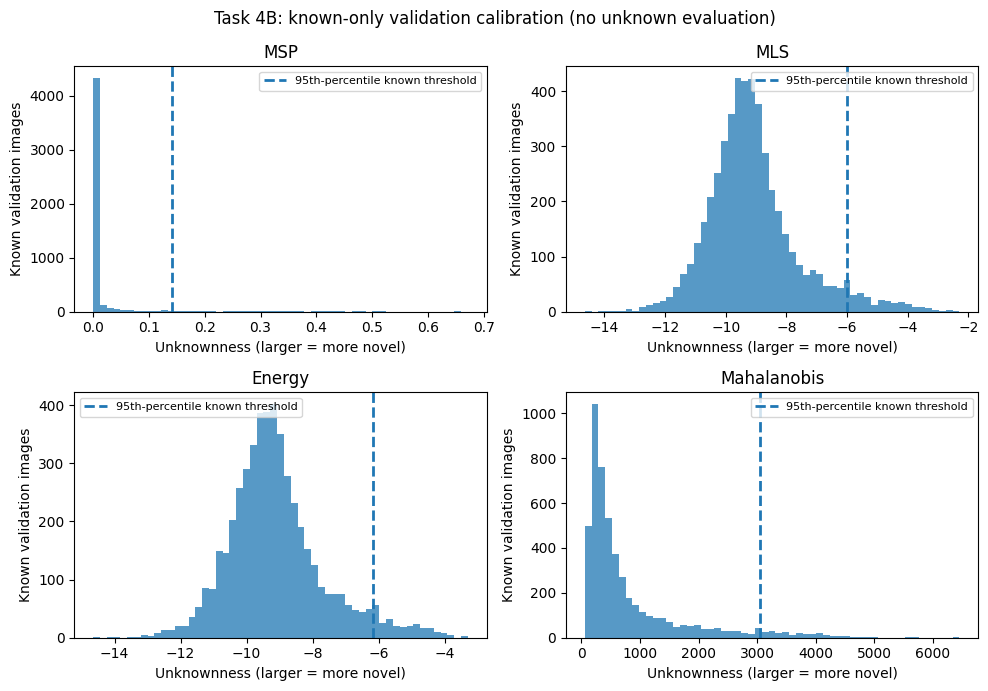

In [8]:
#! Visualize fixed 95th-percentile operating points using known validation only
figure_path = OUT_DIR / 'known_validation_score_distributions.png'
fig, axes = plt.subplots(2, 2, figsize=(10, 7))

for ax, name in zip(axes.flat, SCORE_NAMES):
    ax.hist(val_scores[name], bins=55, alpha=0.75)
    ax.axvline(thresholds[name], linestyle='--', linewidth=2,
               label='95th-percentile known threshold')
    ax.set_title(name)
    ax.set_xlabel('Unknownness (larger = more novel)')
    ax.set_ylabel('Known validation images')
    ax.legend(fontsize=8)

fig.suptitle('Task 4B: known-only validation calibration (no unknown evaluation)')
fig.tight_layout()

if not figure_path.exists():
    fig.savefig(figure_path, dpi=180, bbox_inches='tight')
    print('Saved:', figure_path)
else:
    print('Existing plot retained:', figure_path)

plt.show()


In [9]:
#! Re-read saved files and verify identity, signs, and known-data-only provenance
with np.load(OUT_DIR / 'mahalanobis_reference.npz', allow_pickle=False) as reference:
    if (str(reference['best_checkpoint_sha256'].item()) != BEST_SHA
            or str(reference['score_module_sha256'].item()) != MODULE_SHA
            or not np.array_equal(reference['class_means'], means)
            or not np.array_equal(reference['shared_diagonal_variance'], diagonal_variance)):
        raise RuntimeError('Saved Mahalanobis reference failed provenance check.')

with np.load(OUT_DIR / 'known_validation_scores.npz', allow_pickle=False) as saved:
    if (not np.array_equal(saved['indices'], val_idx)
            or not np.array_equal(saved['labels'], val_labels)
            or str(saved['best_checkpoint_sha256'].item()) != BEST_SHA
            or any(not np.array_equal(saved[name], val_scores[name]) for name in SCORE_NAMES)):
        raise RuntimeError('Saved scores are not the exact same frozen validation rows.')

with (OUT_DIR / 'thresholds_95pct_known_validation.json').open() as handle:
    saved_thresholds = json.load(handle)

if (saved_thresholds['thresholds'] != thresholds
        or saved_thresholds['best_checkpoint_sha256'] != BEST_SHA
        or saved_thresholds['score_module_sha256'] != MODULE_SHA):
    raise RuntimeError('Saved calibration must match these definitions and checkpoint.')

print('TASK 4B COMPLETE: all four scores and thresholds fixed on known data only.')
print('Scores module:', SCORE_FILE)
print('Saved evidence:', OUT_DIR)
print('Next: Task 4C GCSC; do not evaluate unknowns until all checkpoints are fixed.')


TASK 4B COMPLETE: all four scores and thresholds fixed on known data only.
Scores module: /content/drive/MyDrive/pa1-beyond-iid/task4/code/cifar_osr_scores_v1.py
Saved evidence: /content/drive/MyDrive/pa1-beyond-iid/task4/results/posthoc
Next: Task 4C GCSC; do not evaluate unknowns until all checkpoints are fixed.
